## PROYECTO FINAL 
Las plataformas de streaming y los sellos discograficos necesitan entender que caracteristicas musicales hacen que una cancion sea popular o clasificar automaticamente nuevos lanzamientos dentro de su genero correcto para mejorar los algoritmos de recomendacion.

## PASO 1: Definición del problema

## Objetivo de negocio:
 Automatizar la clasificación de géneros musicales para plataformas de streaming y sellos discográficos, reduciendo costos y tiempos de catalogación manual.

## SPOTIFY 
# Estudiantes 
* Daniel Barbosa 
* Maria Veronica Suarez



## Descripcion del conjunto de datos

Este conjunto de datos contiene informacion sobre canciones de Spotify pertenecientes a 125 generos musicales distintos, donde cada fila representa una sola cancion y cada columna representa un atributo especifico relacionado con esa pista. Junto con metadatos basicos como el nombre de la cancion, el artista y la etiqueta de genero, el conjunto de datos incluye varias caracteristicas de audio numericas extraidas por el sistema de analisis de audio de Spotify, tales como danceability (bailabilidad), energy (energia), loudness (sonoridad), speechiness (presencia de voz hablada), acousticness (acustica), instrumentalness (instrumentalidad), liveness (presencia de publico en vivo), valence (positividad musical), tempo (ritmo/PPM) y duration (duracion). Estas caracteristicas describen cuantitativamente las propiedades musicales y el estado de animo de cada pista, lo que hace que el conjunto de datos sea muy adecuado para el analisis de datos, la visualizacion y tareas de aprendizaje automatico (machine learning) como la clasificacion de generos, la agrupacion (clustering), los sistemas de recomendacion y la prediccion del estado de animo. Dado que los datos se proporcionan en formato CSV (valores separados por comas), la informacion es tabular, liviana y facil de cargar en herramientas como Python (Pandas), R, Excel o bases de datos SQL para un rapido procesamiento y modelado. 


## Descripcion de las columnas
* Track_id :Un identificador unico asignado a cada cancion por Spotify.

* Artists :Nombre del artista o artistas que interpretaron la cancion. Los artistas multiples estan separados por un punto y coma (;).

* Album_name :El nombre del album en el que aparece la cancion.

* Track_name :El nombre de la cancion.

* Popularity :Un valor entre 0 y 100 que indica que tan popular es la cancion. Un valor mas alto significa que es mas popular. Se basa principalmente en el numero de reproducciones y en que tan recientes son.

* Duration_ms :La duracion de la cancion en milisegundos.

* Explicit :Indica si la cancion contiene letras explicitas para adultos
    * true = Si
    * false = No o desconocido

* Danceability :Que tan adecuada es la cancion para bailar 
    * 0 = menos bailable
    * 1 = mas bailable.

* Energy :Que tan energica se siente la cancion 
    * 0 = tranquila/suave
    * 1 = muy energica/ruidosa.

* Key :La tonalidad musical de la cancion (p. ej., Do, Re, Mi). 
    * Si no se conoce, el valor es : 1.

* Loudness :La sonoridad general de la cancion en decibelios (dB).

* Mode :Indica la modalidad de la cancion .
    * 1 = Mayor , generalmente suena alegre 
    * 0 = Menor, generalmente suena triste.

* Speechiness :Mide la cantidad de contenido hablado que hay en la cancion. 
    * Cercano a 1 = Principalmente palabras habladas (p. ej., un podcast)
    * Entre 0,33 y 0,66 = Mezcla de voz y musica (p. ej., rap)
    * Por debajo de 0,33 = Principalmente musica

* Acousticness :Probabilidad de que la cancion sea acustica (1 = muy probable que sea acustica).

* Instrumentalness :Probabilidad de que la cancion no tenga voz (1 = sin canto).

* Liveness :Probabilidad de que la cancion haya sido grabada en vivo (un valor mas alto = mayor probabilidad de ser en vivo).

* Valence :Describe el estado de animo de la cancion
    * Valor alto = Alegre/positivo,
    * Valor bajo = Triste/negativo

* Tempo :La velocidad de la cancion medida en pulsaciones por minuto (PPM / BPM).

* Time_signature :Numero de tiempos por compas (generalmente entre 3 y 7).

* Track_genre :La categoria de genero musical de la cancion.






## PASO 2: Obtencion y carga del conjunto de datos

In [98]:
import os
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Descargamos el dataset desde Kaggle
folder_path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

# 2. Buscamos el archivo CSV
csv_name = [f for f in os.listdir(folder_path) if f.endswith(".csv")][0]
file_path = os.path.join(folder_path, csv_name)

# 3. Leemos el DataFrame
df = pd.read_csv(file_path)

# 4. Creamos el directorio si no existe y guardar la copia
output_dir = "../data/raw"
os.makedirs(output_dir, exist_ok=True)  # <-- Se crea la carpeta automáticamente

output_file = os.path.join(output_dir, "spotify-tracks-dataset.csv")
df.to_csv(output_file, index=False)

print("¡Archivo guardado exitosamente en:", output_file)
df.head()

¡Archivo guardado exitosamente en: ../data/raw\spotify-tracks-dataset.csv


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [99]:
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [100]:
df.shape

(114000, 20)

Se tiene un dataset de 114000 filas y 20 columnas 

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

El conjunto de datos esta compuesto por 114.000 filas y 20 columnas. En cuanto a los tipos de variables, incluye 16 numericas, 5 categoricas y 1 booleana.

In [102]:
df.isnull().sum().sort_values(ascending=False)

artists             1
album_name          1
track_name          1
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Con este codigo se evalua los datos faltantes por columna, se observa que el conjunto de datos esta practicamente completo. Unicamente las variables: artists, album_name y track_name contienen 1 valor nulo cada una (correspondiente al mismo registro), mientras que las 19 variables restantes no presentan ningun dato ausente.


In [103]:
df.duplicated().sum()

np.int64(450)

Existen 450 filas completamente duplicadas en todo el DataFrame

In [104]:
df = df.dropna()

df = df.drop_duplicates()

df = df.reset_index(drop=True)

df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113544,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113545,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113546,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113547,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


Se eliminan la fila con los valores nulos, se eliminan las 450 filas duplicadas y se restablece el dataframe 

In [105]:
df.shape

(113549, 20)

Se tiene un dataset de 113549 filas y 20 columnas

## PASO 3: Almacenar la información

In [106]:
import sqlite3
df_sql = df.copy()
conn = sqlite3.connect('../data/raw/spotify_tracks.db')
df_sql.to_sql('spotify_tracks', conn, if_exists='replace', index=False)

query_1 = """
SELECT 
    track_genre, 
    ROUND(AVG(danceability), 3) AS avg_danceability,
    ROUND(AVG(energy), 3) AS avg_energy,
    COUNT(*) AS total_canciones
FROM spotify_tracks
GROUP BY track_genre
ORDER BY avg_danceability DESC
LIMIT 10;
"""

df_sql_1 = pd.read_sql_query(query_1, conn)
print("CONSULTA 1: Top 10 géneros más bailables")
print(df_sql_1)
print("\n" + "="*50 + "\n")


query_2 = """
SELECT 
    track_genre,
    COUNT(CASE WHEN energy > 0.8 THEN 1 END) AS canciones_alta_energia,
    ROUND(AVG(popularity), 2) AS popularidad_promedio,
    ROUND(AVG(tempo), 1) AS tempo_promedio
FROM spotify_tracks
GROUP BY track_genre
ORDER BY canciones_alta_energia DESC
LIMIT 10;
"""

df_sql_2 = pd.read_sql_query(query_2, conn)
print("CONSULTA 2: Géneros con más canciones de alta energía")
print(df_sql_2)


conn.close()

CONSULTA 1: Top 10 géneros más bailables
      track_genre  avg_danceability  avg_energy  total_canciones
0            kids             0.779       0.614              991
1   chicago-house             0.766       0.733              998
2       reggaeton             0.759       0.739             1000
3          latino             0.757       0.731              993
4          reggae             0.745       0.726             1000
5         hip-hop             0.736       0.682              991
6       dancehall             0.734       0.685              999
7  minimal-techno             0.729       0.680              998
8  detroit-techno             0.722       0.710              998
9           latin             0.721       0.727              990


CONSULTA 2: Géneros con más canciones de alta energía
     track_genre  canciones_alta_energia  popularidad_promedio  tempo_promedio
0    death-metal                     936                 32.18           123.8
1      metalcore              

## PASO 4 Y 5: Análisis descriptivo y EDA

### Exploracion de datos

 - conocer distribuciones;
 - identificar asimetría;
 - reconocer valores extremos;
 - conocer categorías simples.


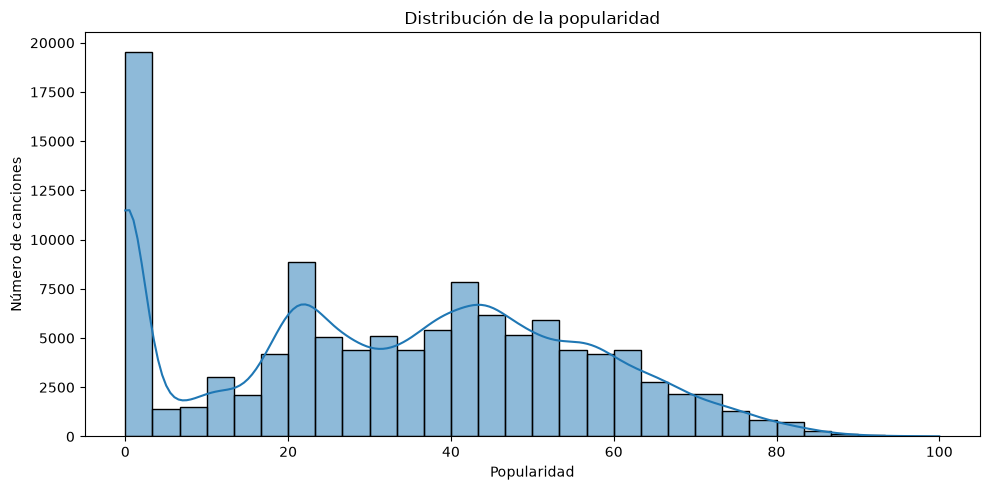

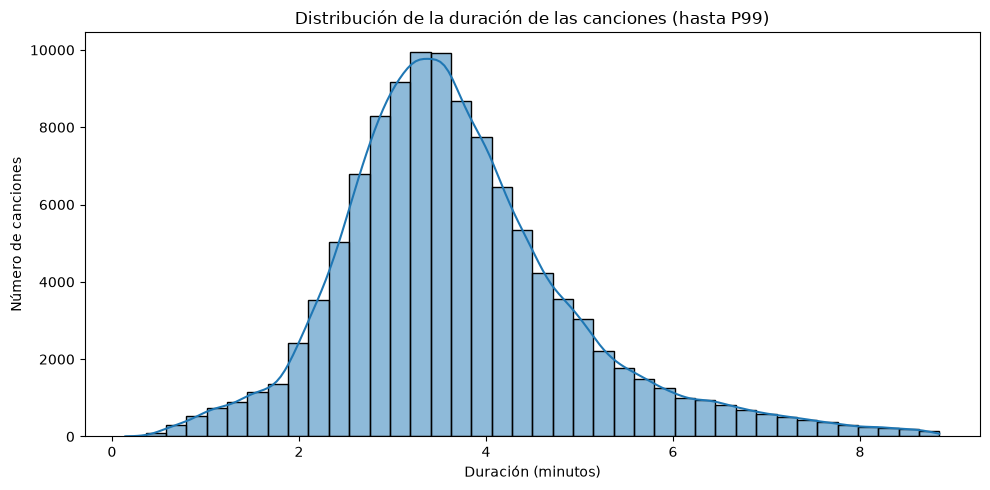

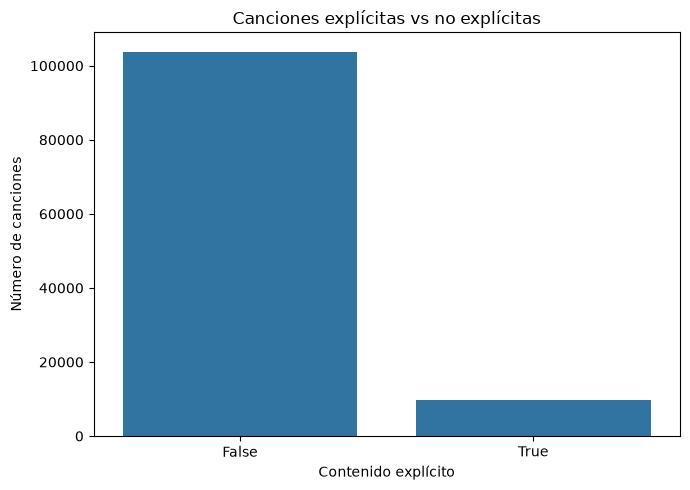

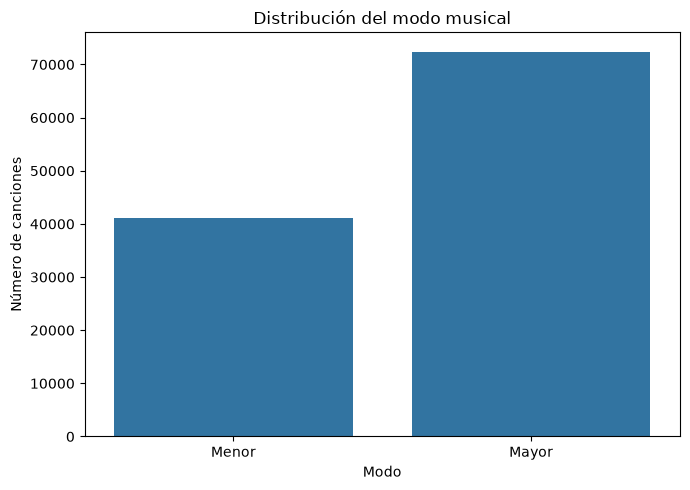

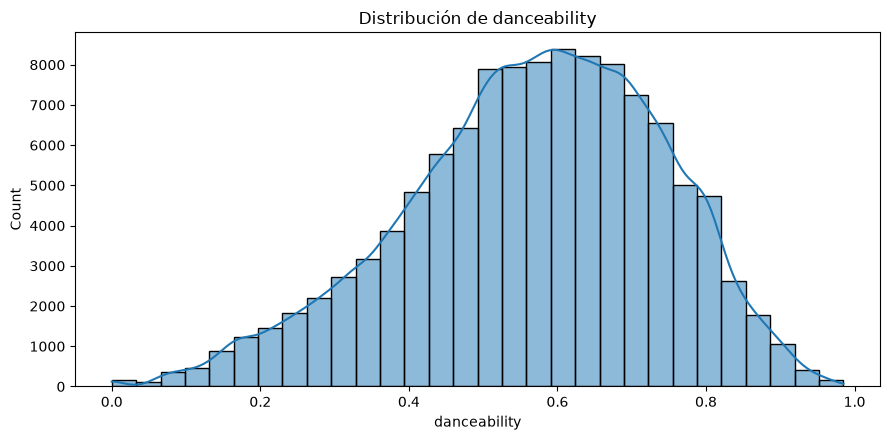

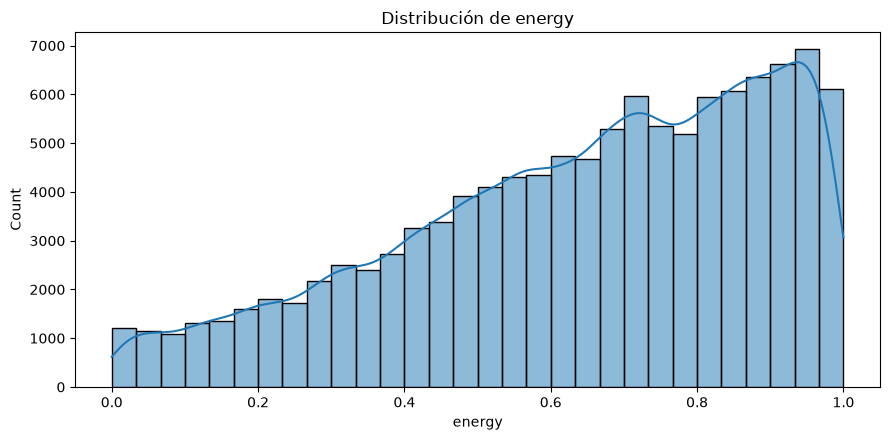

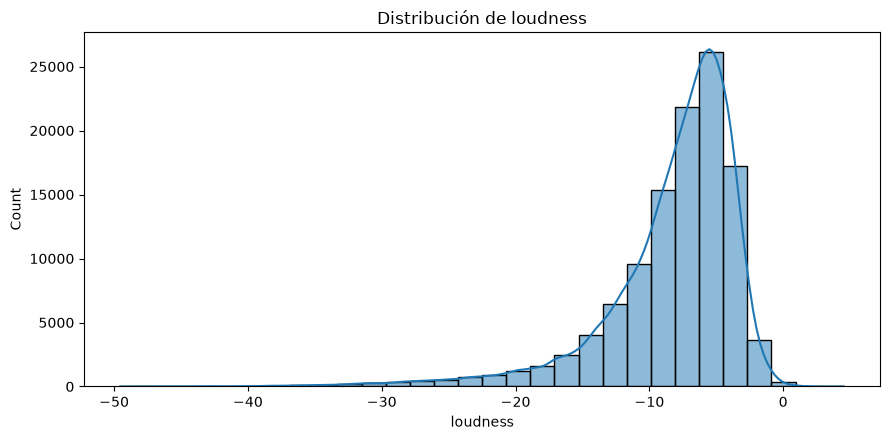

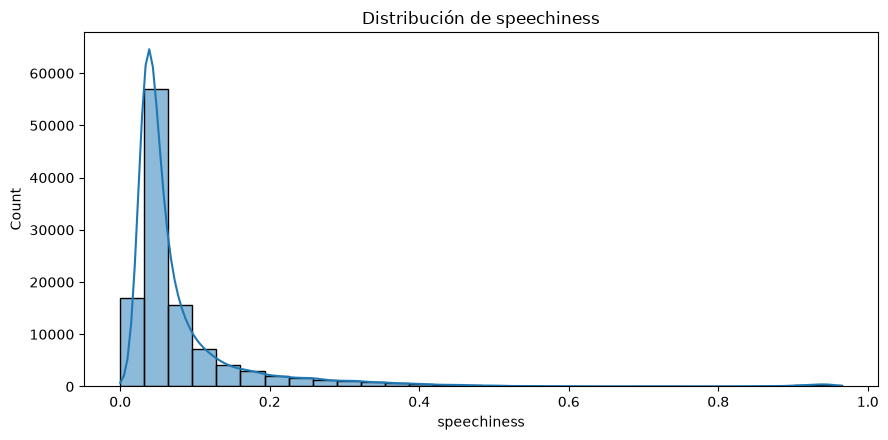

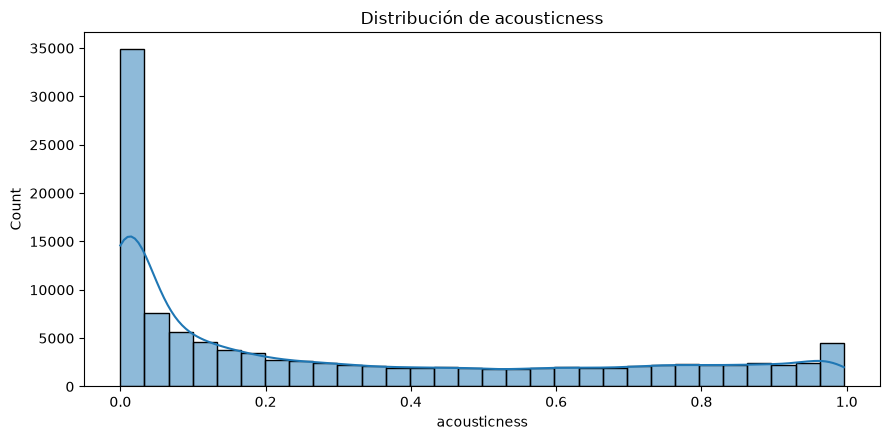

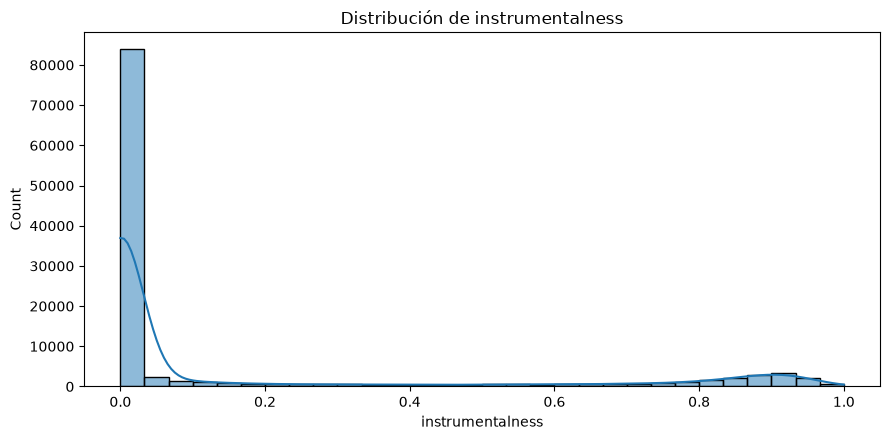

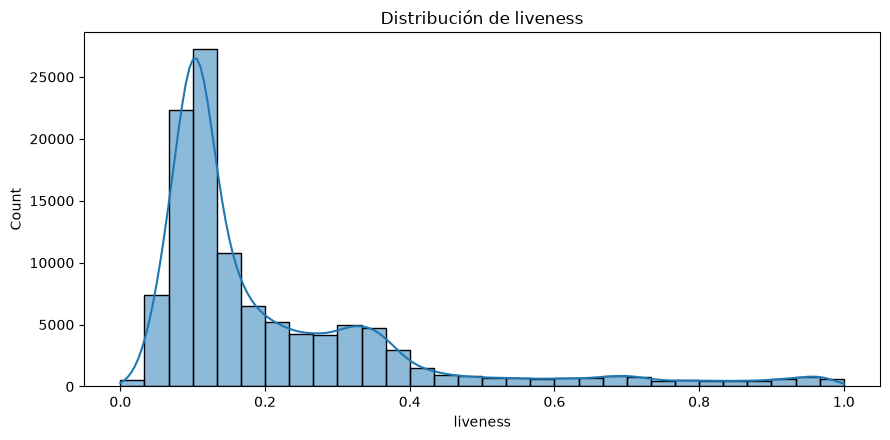

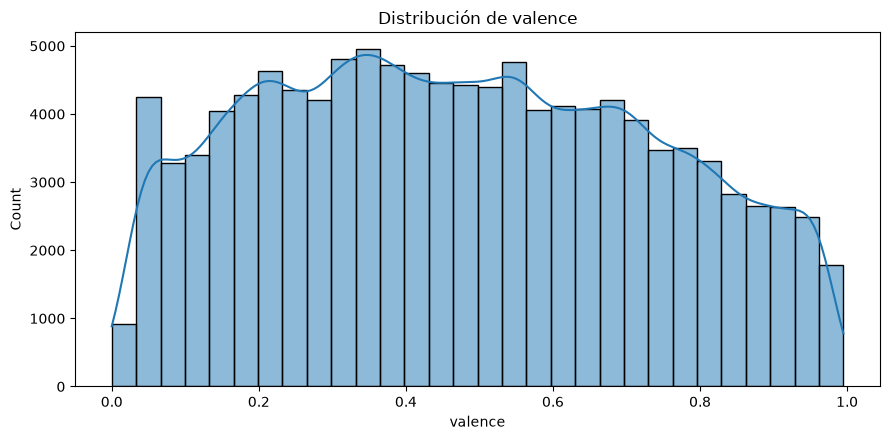

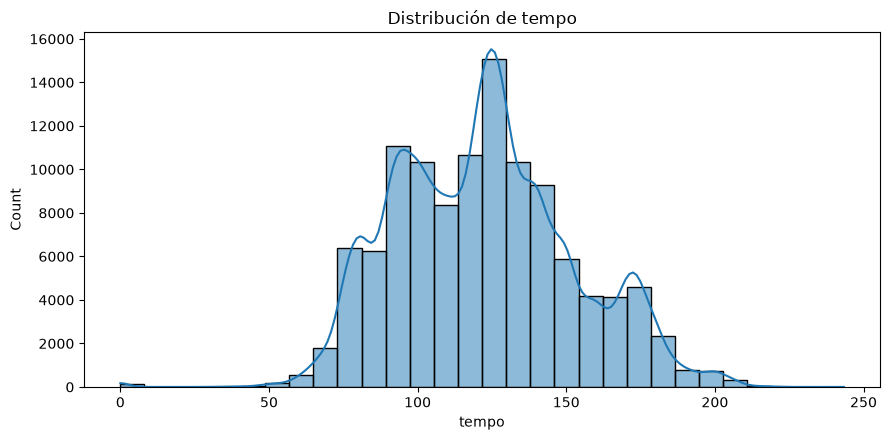

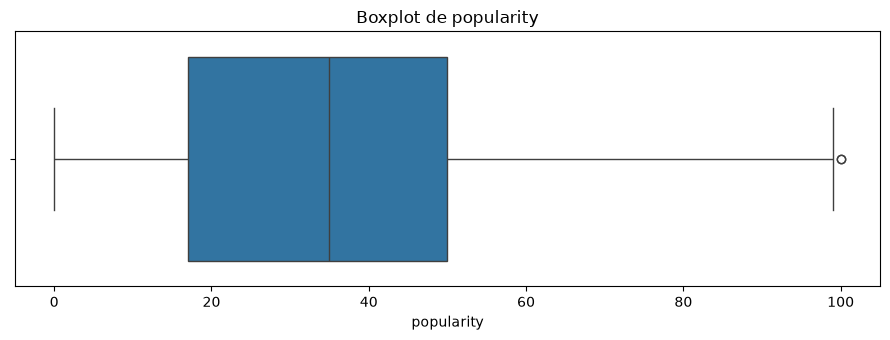

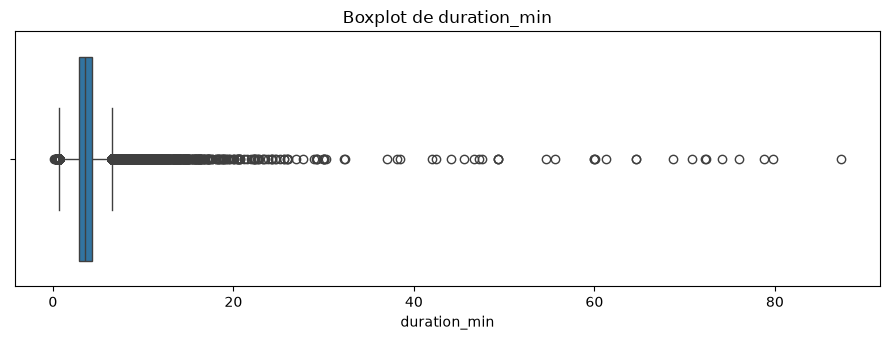

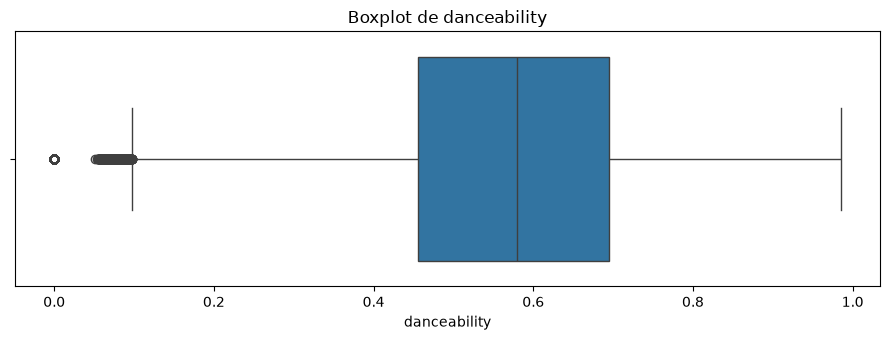

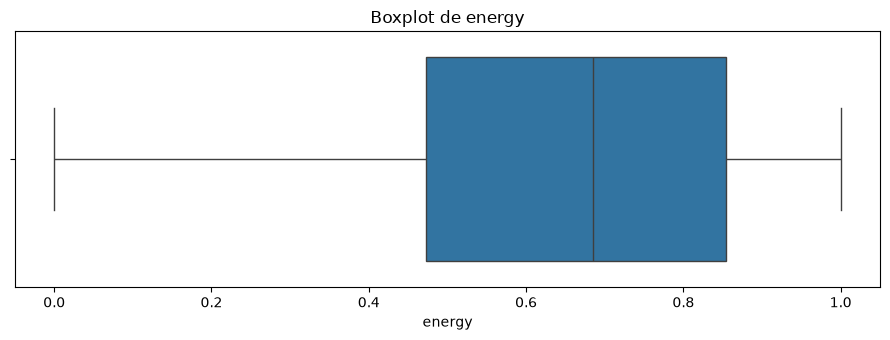

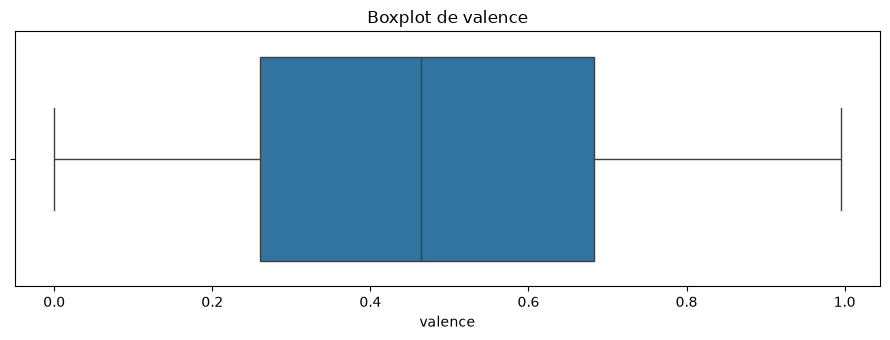

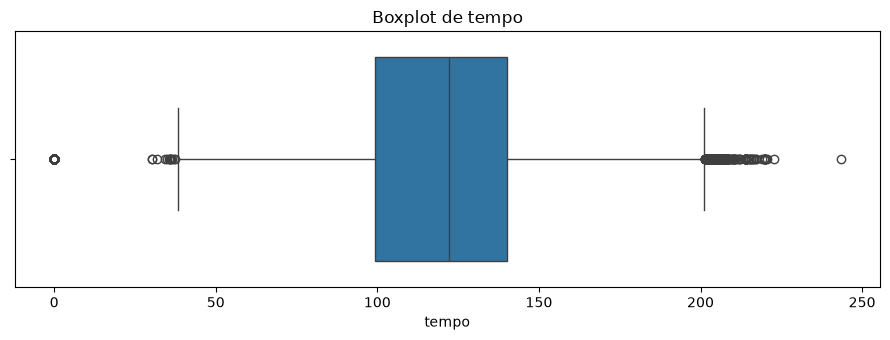

In [107]:
# Convertimos duración de milisegundos a minutos para facilitar interpretación.
if "duration_ms" in df.columns:
    df["duration_min"] = df["duration_ms"] / 60000


# Variables numéricas de audio más útiles para EDA.
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

# 3. DISTRIBUCIÓN DE POPULARIDAD
if "popularity" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=df,
        x="popularity",
        bins=30,
        kde=True
    )
    plt.title("Distribución de la popularidad")
    plt.xlabel("Popularidad")
    plt.ylabel("Número de canciones")
    plt.tight_layout()
    plt.show()


# 4. DISTRIBUCIÓN DE DURACIÓN
if "duration_min" in df.columns:
    # Recorte visual únicamente para evitar que canciones extremadamente
    # largas compriman el histograma. No modifica el dataframe original.
    limite = df["duration_min"].quantile(0.99)
    df_duration = df[df["duration_min"] <= limite]

    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=df_duration,
        x="duration_min",
        bins=40,
        kde=True
    )
    plt.title("Distribución de la duración de las canciones (hasta P99)")
    plt.xlabel("Duración (minutos)")
    plt.ylabel("Número de canciones")
    plt.tight_layout()
    plt.show()


# 5. CANCIONES EXPLÍCITAS VS NO EXPLÍCITAS
if "explicit" in df.columns:
    plt.figure(figsize=(7, 5))
    sns.countplot(
        data=df,
        x="explicit"
    )
    plt.title("Canciones explícitas vs no explícitas")
    plt.xlabel("Contenido explícito")
    plt.ylabel("Número de canciones")
    plt.tight_layout()
    plt.show()


# 6. MODE: TONALIDAD MAYOR / MENOR
if "mode" in df.columns:
    mode_df = df.copy()
    mode_df["mode_label"] = mode_df["mode"].map({
        0: "Menor",
        1: "Mayor"
    }).fillna(mode_df["mode"].astype(str))

    plt.figure(figsize=(7, 5))
    sns.countplot(
        data=mode_df,
        x="mode_label"
    )
    plt.title("Distribución del modo musical")
    plt.xlabel("Modo")
    plt.ylabel("Número de canciones")
    plt.tight_layout()
    plt.show()


# 7. DISTRIBUCIONES DE CARACTERÍSTICAS DE AUDIO
# Se dibujan individualmente para facilitar interpretación.
for variable in audio_features:
    plt.figure(figsize=(9, 4.5))
    sns.histplot(
        data=df,
        x=variable,
        bins=30,
        kde=True
    )
    plt.title(f"Distribución de {variable}")
    plt.tight_layout()
    plt.show()


# 8. BOXPLOTS DE VARIABLES NUMÉRICAS SELECCIONADAS
box_variables = [
    "popularity",
    "duration_min",
    "danceability",
    "energy",
    "valence",
    "tempo",
]

box_variables = [c for c in box_variables if c in df.columns]

for variable in box_variables:
    plt.figure(figsize=(9, 3.5))
    sns.boxplot(
        data=df,
        x=variable
    )
    plt.title(f"Boxplot de {variable}")
    plt.tight_layout()
    plt.show()


### Analisis Univariante 

Para el análisis univariante se seleccionaron principalmente las variables numéricas y categóricas que describen características propias de las canciones, como popularity, duration_ms, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, explicit, key, mode, time_signature y track_genre, ya que permiten analizar distribuciones, frecuencias, dispersión y posibles valores atípicos. Se excluyeron variables como track_id, track_name, album_name y artists porque funcionan principalmente como identificadores o presentan una cardinalidad muy alta, lo que hace menos útil su análisis mediante distribuciones completas; en algunos casos, como artists, pueden explorarse mejor mediante rankings o Top N.


In [108]:
numeric_columns = [
    'popularity',
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

print(df[numeric_columns].describe().T)

                     count           mean            std       min  \
popularity        113549.0      33.324433      22.283855     0.000   
duration_ms       113549.0  228081.370844  106413.098525  8586.000   
danceability      113549.0       0.567031       0.173409     0.000   
energy            113549.0       0.642091       0.251053     0.000   
loudness          113549.0      -8.243408       5.011422   -49.531   
speechiness       113549.0       0.084674       0.105762     0.000   
acousticness      113549.0       0.314064       0.331906     0.000   
instrumentalness  113549.0       0.155703       0.309217     0.000   
liveness          113549.0       0.213613       0.190462     0.000   
valence           113549.0       0.474205       0.259204     0.000   
tempo             113549.0     122.175745      29.972954     0.000   

                          25%            50%          75%          max  
popularity            17.0000      35.000000      50.0000      100.000  
duration_ms  

### Analisis Multivariable

Para el analisis multivariable con este tipo de datasets nos enfocaremos en cómo interactúan varias características musicales al mismo tiempo, especialmente popularity, danceability, energy, valence, acousticness, loudness y algunas variables categóricas como explicit o track_genre.

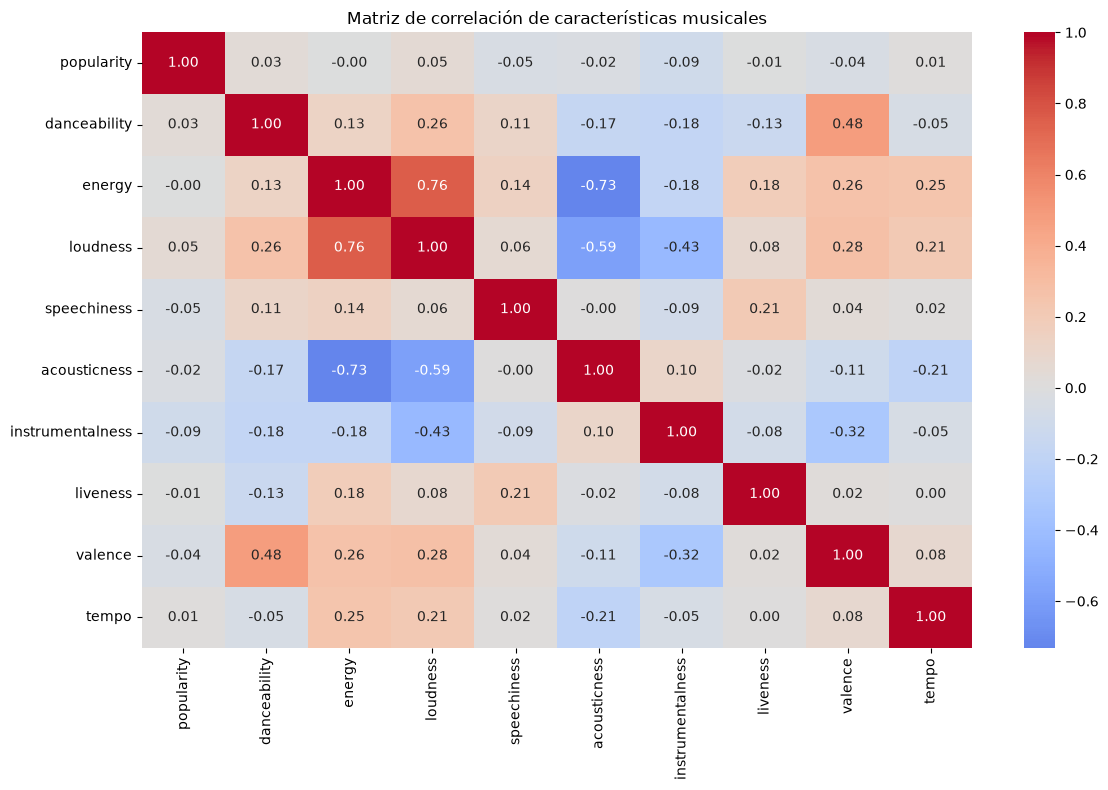

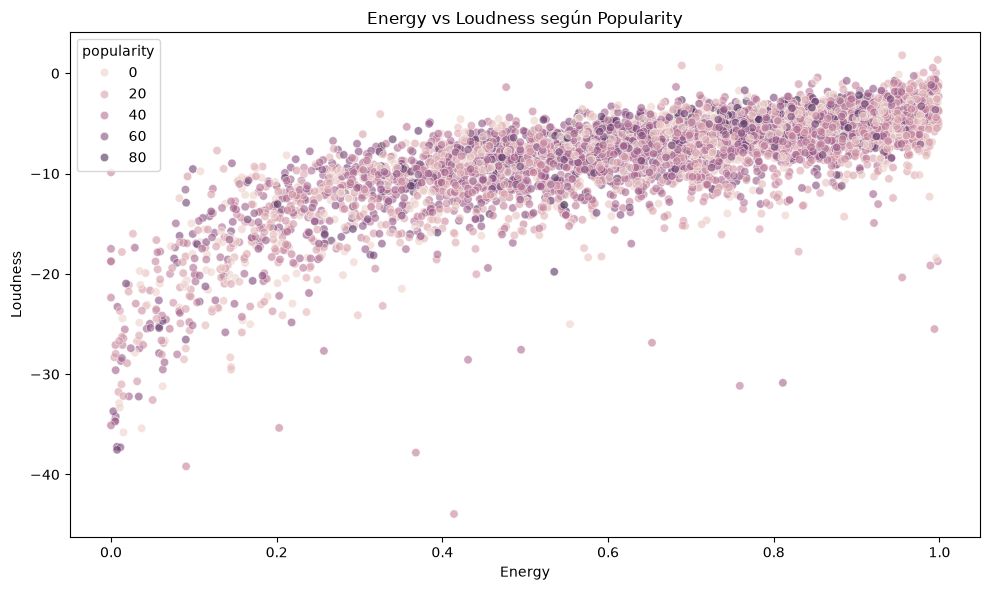

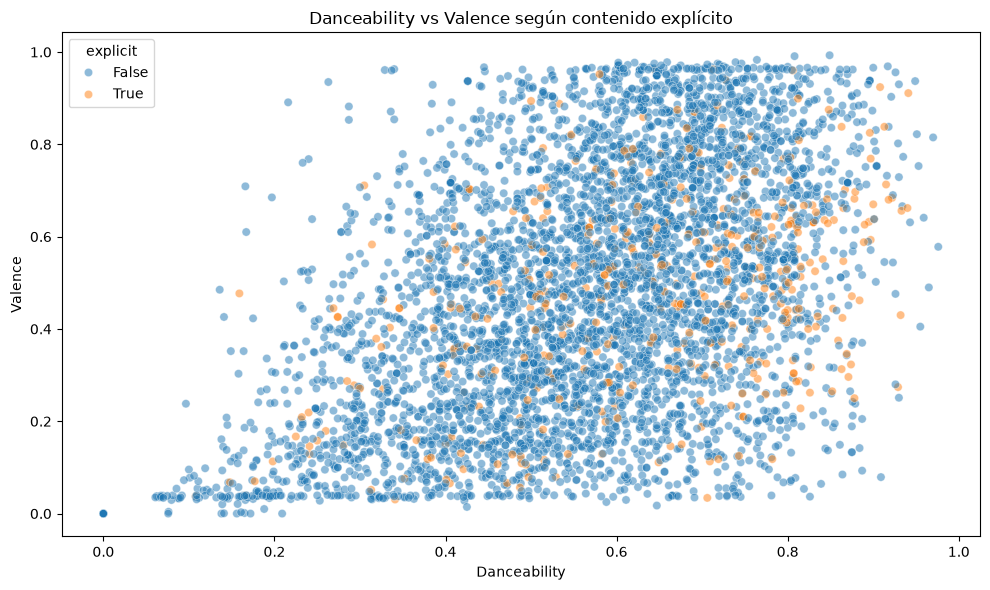

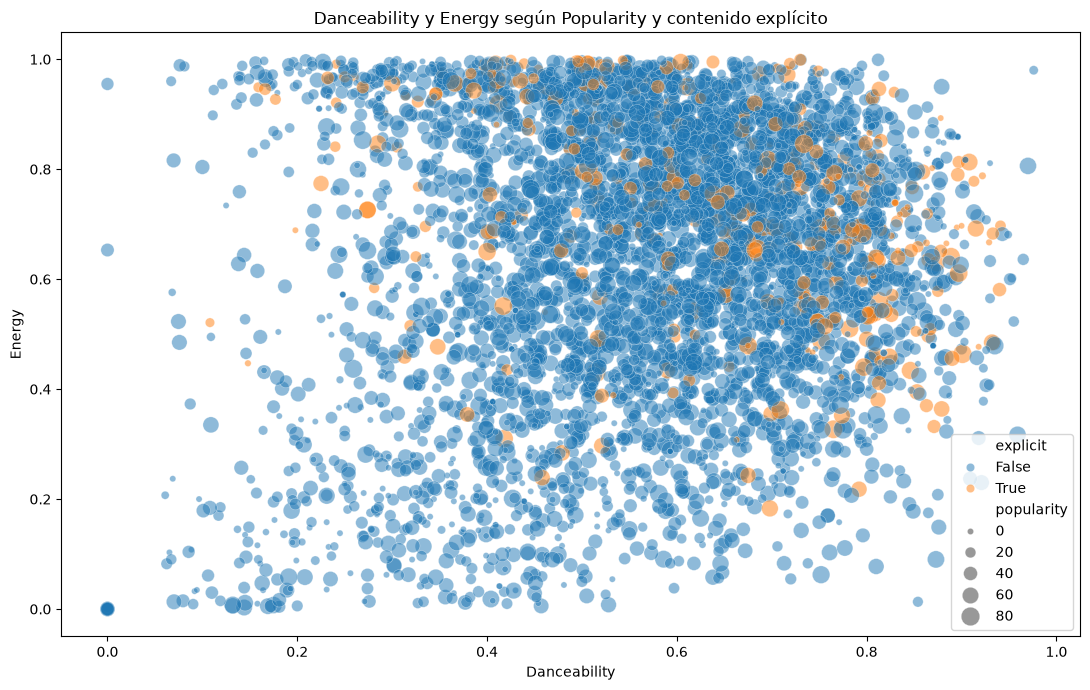


Top 10 géneros por popularidad promedio:
track_genre
pop-film     59.280280
k-pop        56.963928
chill        53.704705
sad          52.379000
grunge       49.582583
indian       49.528529
anime        48.766767
emo          48.128000
pop          47.903323
sertanejo    47.866000
Name: popularity, dtype: float64


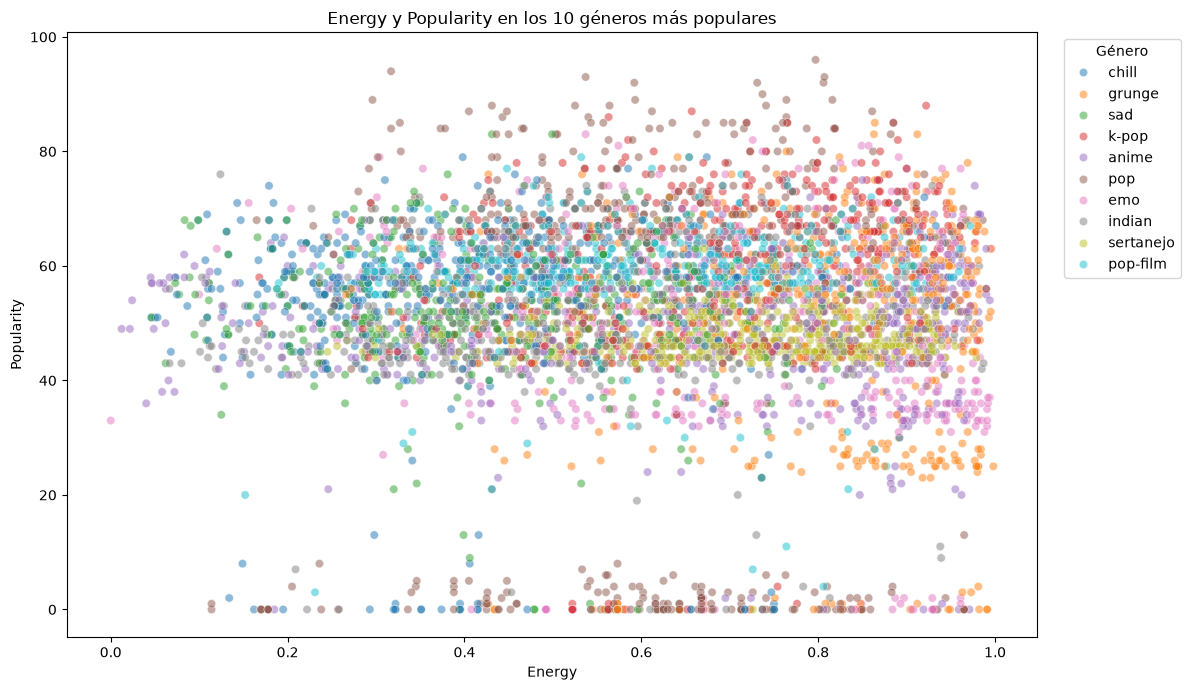

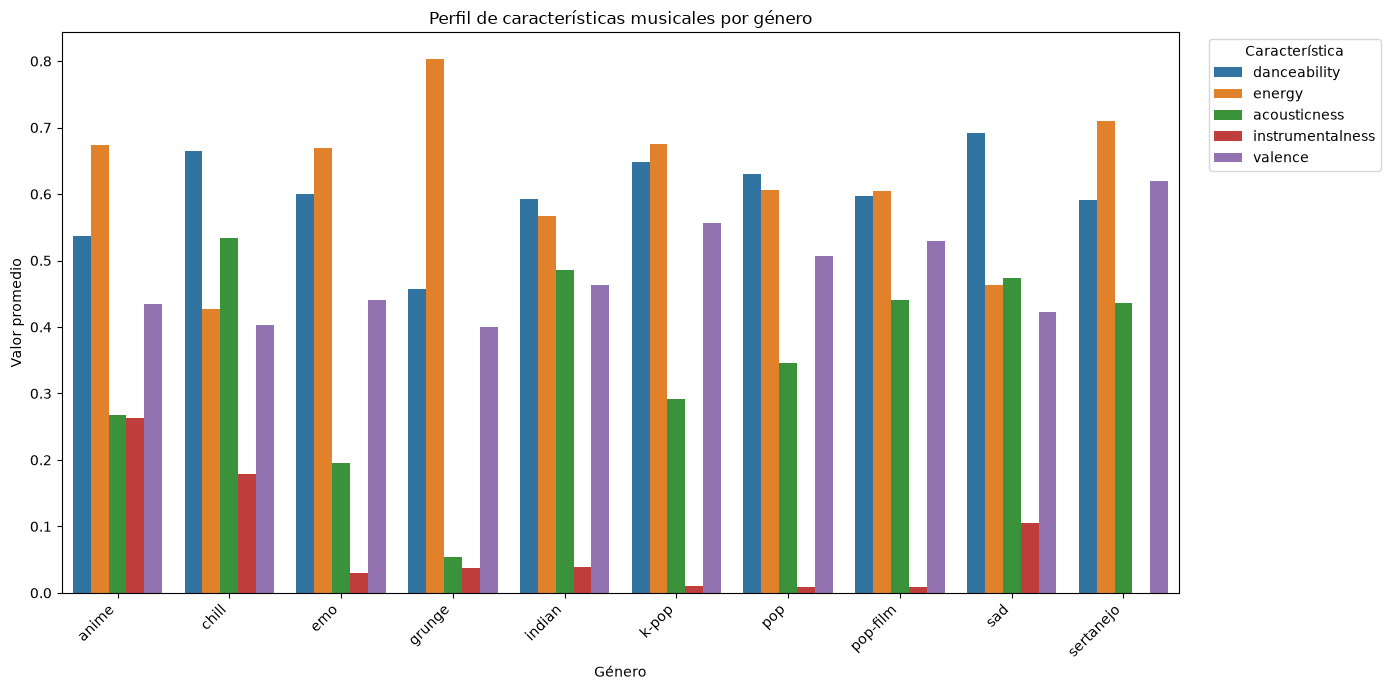

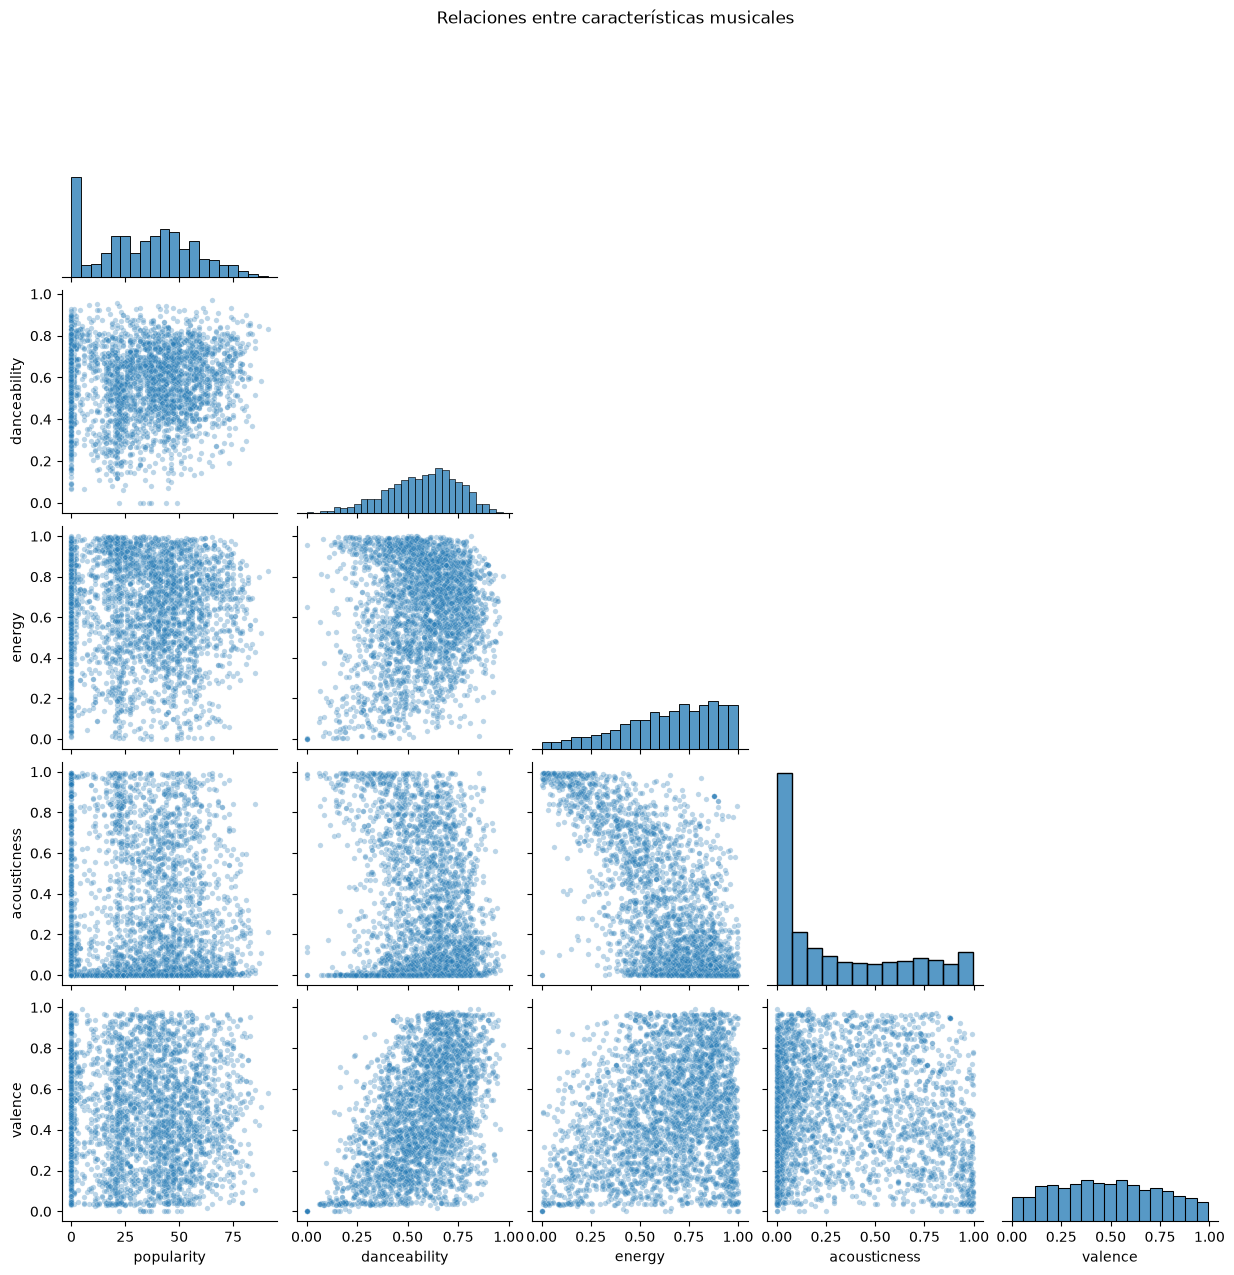


Relaciones con mayor correlación:
          variable_1        variable_2  correlation
23            energy          loudness     0.760624
32          loudness            energy     0.760624
52      acousticness            energy    -0.732747
25            energy      acousticness    -0.732747
35          loudness      acousticness    -0.588111
53      acousticness          loudness    -0.588111
18      danceability           valence     0.476755
81           valence      danceability     0.476755
36          loudness  instrumentalness    -0.432109
63  instrumentalness          loudness    -0.432109
68  instrumentalness           valence    -0.324314
86           valence  instrumentalness    -0.324314
83           valence          loudness     0.279428
38          loudness           valence     0.279428
82           valence            energy     0.258451
28            energy           valence     0.258451
13      danceability          loudness     0.256559
31          loudness      dan

In [109]:
# =========================================================
# 1. MATRIZ DE CORRELACIÓN
# =========================================================

variables_corr = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

corr = df[variables_corr].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de correlación de características musicales')
plt.tight_layout()
plt.show()


# =========================================================
# 2. MUESTRA PARA GRÁFICOS DE DISPERSIÓN
# =========================================================

sample_df = df.sample(
    n=min(5000, len(df)),
    random_state=42
)


# =========================================================
# 3. ENERGY VS LOUDNESS SEGÚN POPULARITY
# =========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x='energy',
    y='loudness',
    hue='popularity',
    alpha=0.6
)

plt.title('Energy vs Loudness según Popularity')
plt.xlabel('Energy')
plt.ylabel('Loudness')

plt.tight_layout()
plt.show()


# =========================================================
# 4. DANCEABILITY VS VALENCE SEGÚN EXPLICIT
# =========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x='danceability',
    y='valence',
    hue='explicit',
    alpha=0.5
)

plt.title('Danceability vs Valence según contenido explícito')
plt.xlabel('Danceability')
plt.ylabel('Valence')

plt.tight_layout()
plt.show()


# =========================================================
# 5. DANCEABILITY VS ENERGY
#    POPULARITY = TAMAÑO
#    EXPLICIT = COLOR
# =========================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=sample_df,
    x='danceability',
    y='energy',
    hue='explicit',
    size='popularity',
    sizes=(20, 200),
    alpha=0.5
)

plt.title(
    'Danceability y Energy según Popularity y contenido explícito'
)

plt.xlabel('Danceability')
plt.ylabel('Energy')

plt.tight_layout()
plt.show()


# =========================================================
# 6. TOP 10 GÉNEROS SEGÚN POPULARIDAD PROMEDIO
# =========================================================

top_genres = (
    df.groupby('track_genre')['popularity']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .index
)

df_top_genres = df[
    df['track_genre'].isin(top_genres)
].copy()

print("\nTop 10 géneros por popularidad promedio:")

print(
    df_top_genres
    .groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
)


# =========================================================
# 7. ENERGY VS POPULARITY POR GÉNERO
# =========================================================

sample_genres = df_top_genres.sample(
    n=min(5000, len(df_top_genres)),
    random_state=42
)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=sample_genres,
    x='energy',
    y='popularity',
    hue='track_genre',
    alpha=0.5
)

plt.title(
    'Energy y Popularity en los 10 géneros más populares'
)

plt.xlabel('Energy')
plt.ylabel('Popularity')

plt.legend(
    title='Género',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


# =========================================================
# 8. PERFIL MUSICAL POR GÉNERO
# =========================================================

features = [
    'danceability',
    'energy',
    'acousticness',
    'instrumentalness',
    'valence'
]

perfil_genero = (
    df_top_genres
    .groupby('track_genre')[features]
    .mean()
    .reset_index()
)

perfil_long = perfil_genero.melt(
    id_vars='track_genre',
    var_name='feature',
    value_name='mean'
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=perfil_long,
    x='track_genre',
    y='mean',
    hue='feature'
)

plt.title(
    'Perfil de características musicales por género'
)

plt.xlabel('Género')
plt.ylabel('Valor promedio')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.legend(
    title='Característica',
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()


# =========================================================
# 9. PAIRPLOT
# =========================================================

variables_pairplot = [
    'popularity',
    'danceability',
    'energy',
    'acousticness',
    'valence'
]

pair_base = df[
    variables_pairplot
].dropna()

pair_df = pair_base.sample(
    n=min(3000, len(pair_base)),
    random_state=42
)

sns.pairplot(
    pair_df,
    corner=True,
    diag_kind='hist',
    plot_kws={
        'alpha': 0.3,
        's': 15
    }
)

plt.suptitle(
    'Relaciones entre características musicales',
    y=1.02
)

plt.show()


# =========================================================
# 10. CORRELACIONES MÁS IMPORTANTES
# =========================================================

corr_pairs = (
    corr
    .where(
        ~pd.DataFrame(
            False,
            index=corr.index,
            columns=corr.columns
        )
    )
)

# Convertimos la matriz a formato largo
corr_long = (
    corr
    .stack()
    .reset_index()
)

corr_long.columns = [
    'variable_1',
    'variable_2',
    'correlation'
]

# Eliminamos correlaciones de una variable consigo misma
corr_long = corr_long[
    corr_long['variable_1']
    != corr_long['variable_2']
].copy()

corr_long['abs_correlation'] = (
    corr_long['correlation'].abs()
)

corr_long = (
    corr_long
    .sort_values(
        'abs_correlation',
        ascending=False
    )
)

print("\nRelaciones con mayor correlación:")

print(
    corr_long[
        [
            'variable_1',
            'variable_2',
            'correlation'
        ]
    ].head(20)
)



In [110]:
genre_distribution = df['track_genre'].value_counts()

print(genre_distribution)
print(genre_distribution.describe())

track_genre
acoustic      1000
british       1000
country       1000
disco         1000
electronic    1000
              ... 
honky-tonk     981
dance          965
german         963
classical      933
romance        904
Name: count, Length: 114, dtype: int64
count     114.000000
mean      996.043860
std        11.844412
min       904.000000
25%       998.000000
50%       999.000000
75%      1000.000000
max      1000.000000
Name: count, dtype: float64


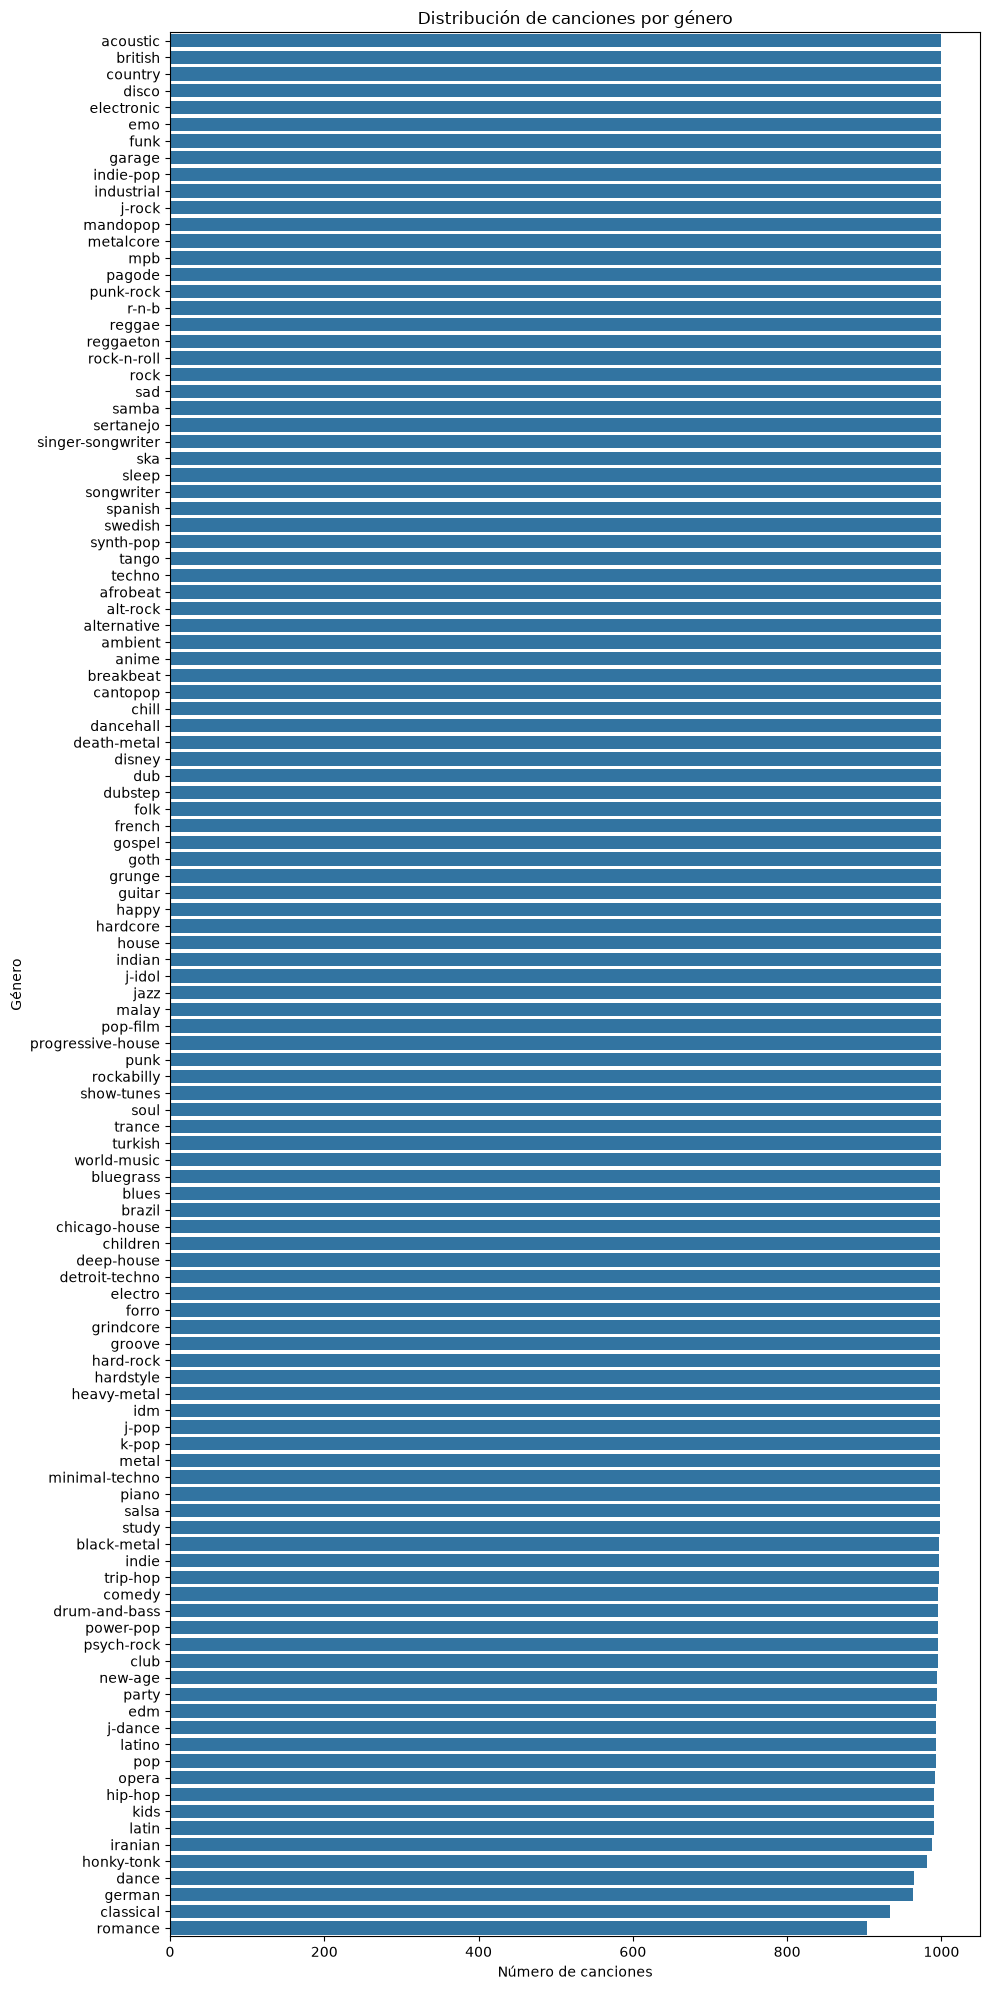

In [111]:
plt.figure(figsize=(10, 20))

sns.countplot(
    data=df,
    y='track_genre',
    order=df['track_genre'].value_counts().index
)

plt.title('Distribución de canciones por género')
plt.xlabel('Número de canciones')
plt.ylabel('Género')

plt.tight_layout()
plt.show()

### Grafico de Barras 

Se hizo para validar la distribución de observaciones por cada categoría de track_genre antes de entrenar el modelo, ya que un desbalance fuerte podría sesgar la clasificación hacia los géneros con más registros. El resultado muestra que la mayoría de los géneros tienen cantidades de observaciones muy similares, con diferencias relativamente pequeñas, por lo que el dataset puede considerarse suficientemente balanceado para continuar con el modelado sin aplicar inicialmente técnicas como oversampling, undersampling o SMOTE.

### Conclusiones EDA

- Matriz de correlación: Se observa una relación positiva fuerte entre energy y loudness, mientras que energy y acousticness presentan una relación negativa importante. La mayoría de las demás variables muestran correlaciones bajas o moderadas, lo que indica que cada característica aporta información diferente al análisis.

- Energy vs Loudness y Popularity: Las canciones con mayor energy tienden a presentar también valores más altos de loudness, confirmando la correlación observada previamente. La popularity, sin embargo, se encuentra distribuida a lo largo de toda la relación y no muestra un patrón claramente diferenciable.

- Danceability vs Valence y Explicit: Se aprecia una relación positiva moderada entre danceability y valence, indicando que las canciones más bailables tienden a presentar un carácter musical más positivo. Las canciones explícitas y no explícitas presentan una alta superposición.

- Danceability vs Energy, Popularity y Explicit: No existe una separación clara entre canciones explícitas y no explícitas considerando simultáneamente danceability y energy. La popularidad tampoco se concentra en una región específica, sugiriendo que estas variables individuales no son suficientes para explicar por sí solas la popularidad.

- Energy vs Popularity por género: Los diferentes géneros presentan una importante superposición en sus niveles de energy y popularity. Esto indica que energy por sí sola posee una capacidad limitada para identificar el género de una canción.

- Perfil acústico por género: Al combinar danceability, energy, acousticness, instrumentalness y valence aparecen diferencias más claras entre los perfiles de los géneros. Esto sugiere que la combinación de varias características acústicas será más útil para la clasificación que utilizar una sola variable.

- Pairplot: Las relaciones entre las características acústicas muestran principalmente patrones débiles o moderados, destacando energy–acousticness y danceability–valence. La ausencia de separaciones simples confirma que el problema requiere considerar múltiples variables simultáneamente.

- Distribución de track_genre: Los géneros presentan cantidades de observaciones similares, con diferencias relativamente pequeñas entre las categorías. Por lo tanto, no se identifica un problema significativo de desbalance de clases y no es necesario aplicar técnicas de balanceo artificial inicialmente.

### Conclusión general del EDA

 Las características acústicas individuales no permiten distinguir claramente los géneros debido a la considerable superposición entre ellos. Sin embargo, los perfiles multivariables sí muestran diferencias, por lo que existe evidencia suficiente para continuar con un modelo de clasificación multiclase que combine varias características acústicas para predecir track_genre.

## PASO 6: Construccion del modelo y optimizacion 

In [112]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Definición de variables predictoras y objetivo
audio_features = [
    "danceability", "energy", "loudness", "speechiness", 
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

X = df[audio_features + ['popularity', 'explicit']]
y = df['track_genre']

# 2. División del conjunto de datos en Train y Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Entrenamiento del modelo
print("Entrenando el modelo RandomForest...")
clf = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# 4. Evaluación del modelo
y_pred = clf.predict(X_test)
print("\n REPORTE DE CLASIFICACIÓN \n")
print(classification_report(y_test, y_pred))

# 5. Guardado del modelo 
joblib.dump(clf, 'modelo_spotify_genre.pkl')
print("\n¡Modelo guardado exitosamente como 'modelo_spotify_genre.pkl'!")


Entrenando el modelo RandomForest...

 REPORTE DE CLASIFICACIÓN 

                   precision    recall  f1-score   support

         acoustic       0.11      0.19      0.14       200
         afrobeat       0.30      0.24      0.27       200
         alt-rock       0.00      0.00      0.00       200
      alternative       0.10      0.04      0.06       200
          ambient       0.27      0.28      0.27       200
            anime       0.14      0.06      0.08       200
      black-metal       0.51      0.62      0.56       199
        bluegrass       0.30      0.45      0.36       199
            blues       1.00      0.01      0.01       200
           brazil       0.19      0.03      0.05       200
        breakbeat       0.54      0.33      0.41       200
          british       0.00      0.00      0.00       200
         cantopop       0.15      0.18      0.17       200
    chicago-house       0.47      0.42      0.45       200
         children       0.21      0.18      0.20

* Se definio las variables de entrada numéricas y categóricas para X, y la variable track_genre para y. 

* Se realizo la división del dataset en 80 % entrenamiento y 20 % prueba.

* Se insta y entrena el modelo RandomForestClassifier especificando la profundidad máxima y el número de estimadores.  

* Se efectuo la predicción sobre el conjunto de prueba para obtener la precisión y el reporte de clasificación.  

* Se guardo el objeto del modelo en disco mediante joblib. 



* Desempeño general (30% de aciertos): Un 30% puede sonar bajo, pero al tener 114 géneros diferentes, adivinar al azar solo daría un 0,87%. El modelo es 34 veces más inteligente que el azar.

* Géneros fáciles de detectar: Las canciones con características muy marcadas destacan mucho. Por ejemplo, comedy (89% de acierto) se detecta fácil por la voz hablada, y géneros como country (58%) o black-metal (54%) tienen ritmos y sonidos muy únicos.

* Géneros difíciles de diferenciar: Subgéneros como alt-rock (3%) o alternative (6%) se confunden casi siempre porque sus niveles de energía, ritmo y volumen son prácticamente idénticos a los del rock o pop común.

* Datos balanceados: La columna support demuestra que el examen fue justo, evaluando unas 200 canciones por cada género.